Este notebook foi criado para importar a tabela de Resíduos Sólidos em Excel para o ambiente do Google Colab. Aqui mostraremos a importação da tabela, assim como a criação das tabelas.

In [4]:
# Importação das bibliotecas que utilizaremos
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Importação do arquivo de tabela a ser utilizado, através do path na seção "Files" do Colab, contendo as informações de resíduos sólidos
file='./Solid_waste_pt.xlsx'

In [6]:
# Visão geral da tabela
df=pd.read_excel(file)
df

,Regiao_Coleta,Tipo_Residuo,Origem_Residuo,Metodo_Destinacao,Massa_Coletada_kg,Densidade_Residuo_kgm3,Umidade_Residuo_pct,Distancia_Destinacao_km,Custo_Coleta_Transporte_RS_ton,Indice_Reciclabilidade_pct,Poder_Calorifico_MJkg
0,Zona Sul,Reciclável,Comercial,Aterro Sanitário,1057.3,80.8,2.0,14.7,138.7,79.7,15.1
1,Zona Oeste,Reciclável,Comercial,Reciclagem,533.3,82.4,2.0,9.1,119.1,85.4,17.9
2,Centro,Reciclável,Comercial,Reciclagem,529.7,72.7,2.0,24.0,223.2,81.6,13.9
3,Zona Oeste,Reciclável,Comercial,Reciclagem,486.3,67.4,2.0,3.6,117.9,82.0,18.8
4,Zona Leste,Reciclável,Comercial,Aterro Sanitário,527.1,40.0,2.0,16.7,164.2,88.0,14.7
...,...,...,...,...,...,...,...,...,...,...,...
285,Zona Leste,Orgânico,Residencial,Aterro Sanitário,275.9,371.8,77.0,17.2,178.8,5.2,6.5
286,Zona Norte,Orgânico,Comercial,Aterro Sanitário,471.8,338.4,77.2,52.9,262.3,5.0,8.1
287,Zona Leste,Orgânico,Residencial,Aterro Sanitário,356.3,341.2,77.6,18.0,184.2,10.1,3.6
288,Zona Oeste,Orgânico,Comercial,Reciclagem,674.9,316.9,78.5,5.1,94.1,8.1,8.8


In [7]:
# Tabela que mostra a quantidade de coletas realizadas em cada regiao
df_Origem_Residuo=df.Origem_Residuo.value_counts()
df_Origem_Residuo

,count
Origem_Residuo,
Residencial,143
Comercial,67
Industrial,58
Serviços de Saúde,22


In [8]:
# Impressão do total das coletas realizadas
total_df_Origem_Residuo=df_Origem_Residuo.sum()
total_df_Origem_Residuo

np.int64(290)

In [9]:
# Impressão da tabela com as Regiões de Coleta ordenadas de forma alfabética
dados_v_Origem_Residuo=pd.DataFrame(df_Origem_Residuo)
dados_v_Origem_Residuo

,count
Origem_Residuo,
Residencial,143
Comercial,67
Industrial,58
Serviços de Saúde,22


In [10]:
# Reinicia os índices da região de coleta
dados_v_Origem_Residuo=pd.DataFrame(df_Origem_Residuo).reset_index()
# Renomeia as colunas na tabela com o total de resíduos coletados em cada região da cidade
dados_v_Origem_Residuo.columns=['Origem do Resíduo','Frequência absoluta']
dados_v_Origem_Residuo

print(dados_v_Origem_Residuo)


   Origem do Resíduo  Frequência absoluta
0        Residencial                  143
1          Comercial                   67
2         Industrial                   58
3  Serviços de Saúde                   22


In [11]:
# Cálculo da frequência relativa
dados_v_Origem_Residuo['Frequência relativa(%)']=round((dados_v_Origem_Residuo['Frequência absoluta']/total_df_Origem_Residuo)*100,2)
print(dados_v_Origem_Residuo)

   Origem do Resíduo  Frequência absoluta  Frequência relativa(%)
0        Residencial                  143                   49.31
1          Comercial                   67                   23.10
2         Industrial                   58                   20.00
3  Serviços de Saúde                   22                    7.59


In [12]:
# Criação de uma tabela com os dados de total de resíduos sólidos de cada região e a frequência relativa de porcentagem de cada região
tabela_Dados_v_Origem_Residuo=pd.DataFrame(dados_v_Origem_Residuo)
tabela_Dados_v_Origem_Residuo

,Origem do Resíduo,Frequência absoluta,Frequência relativa(%)
0,Residencial,143,49.31
1,Comercial,67,23.10
2,Industrial,58,20.00
3,Serviços de Saúde,22,7.59


In [13]:
# inserção das frequências acumulativas relativa e absoluta na tabela
tabela_Dados_v_Origem_Residuo['Frequência absoluta acumulada']=tabela_Dados_v_Origem_Residuo['Frequência absoluta'].cumsum()
tabela_Dados_v_Origem_Residuo['Frequência relativa acumulada(%)']=tabela_Dados_v_Origem_Residuo['Frequência relativa(%)'].cumsum()
tabela_Dados_v_Origem_Residuo

,Origem do Resíduo,Frequência absoluta,Frequência relativa(%),Frequência absoluta acumulada,Frequência relativa acumulada(%)
0,Residencial,143,49.31,143,49.31
1,Comercial,67,23.10,210,72.41
2,Industrial,58,20.00,268,92.41
3,Serviços de Saúde,22,7.59,290,100.00


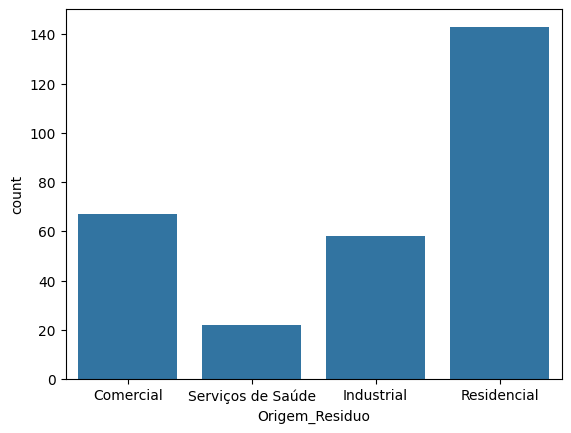

In [14]:
sns.countplot(x='Origem_Residuo',data=df)
plt.show()

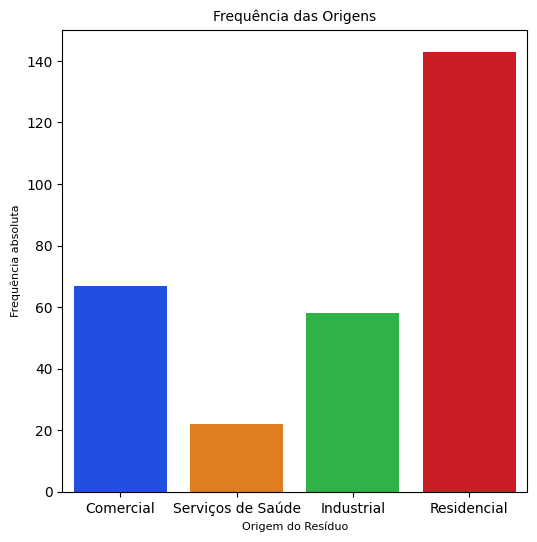

In [15]:
#ajustando os eixos da figura para melhor visualização e dando nomes aos eixos
fig,ax=plt.subplots(figsize=(6,6))
sns.countplot(x='Origem_Residuo',data=df,hue="Origem_Residuo",palette='bright', legend=False)
ax.set_xlabel("Origem do Resíduo", size=8)
ax.set_ylabel("Frequência absoluta",size=8)
ax.set_title("Frequência das Origens",size=10)
plt.show()

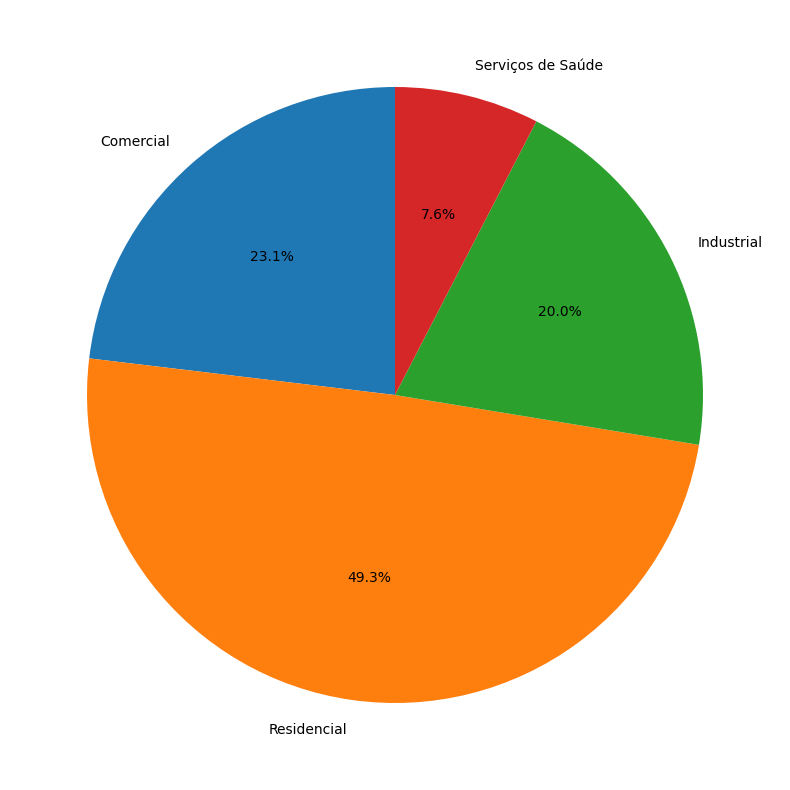

In [16]:
rótulos=['Comercial', 'Residencial', 'Industrial', 'Serviços de Saúde']
valores=[67, 143, 58, 22]
plt.figure(figsize=(10,10))
plt.pie(valores,labels=rótulos,autopct='%1.1f%%',startangle=90)
plt.show()


Existem 143 registros de resíduos sólidos de origem residencial na base de dados. Sendo assim, a origem de resíduo Residencial é a informação da variável de "Origem de Resíduo" que mais se repete ao longo da base de dados.

In [17]:
df.Origem_Residuo.mode()

,Origem_Residuo
0,Residencial


In [18]:
tabela_Dados_v_Origem_Residuo.to_excel("Tabela_Variaveis_Escolhidas.xlsx",sheet_name="Dados",index=False)